# 12 — Terrain Transition Detection Analysis

## Motivation

Standard classification metrics (accuracy, macro-F1) treat every 2-second window equally. For a mobile robot navigating variable terrain, *temporal* performance matters: how quickly after a ground-truth terrain change does the classifier commit to the new class?

A model that detects a transition from grass to muddy dirt within 3 seconds allows the controller to adapt before wheel slip occurs. One that takes 50 seconds — or never detects it — provides no useful early warning.

This notebook quantifies **transition detection latency** for all six classifiers trained in earlier notebooks, using **tuned** hyperparameters throughout to ensure the comparison reflects each model's best achievable behaviour.

## Methodology

- **Data**: `dataset_A_pruned_5run.csv` — 2,346 windows (2 s duration, 1 s step, 5 runs). 123 hand-crafted IMU + odometry features covering statistical moments, spectral energy, autocorrelation, and cross-channel correlations.
- **Raw windows**: `raw_windows_cnn.parquet` — 5 IMU channels (ax, ay, az, gx, gz) at 100 Hz for the CNN. gy/yaw excluded as it encodes steering geometry rather than terrain texture.
- **Models evaluated**:
  - Classical (sklearn Pipelines): LogisticRegression, RandomForest, XGBoost, SVM — with **tuned** hyperparameters from `results/tuning_best_params.json`.
  - MLP: 3-layer [256, 128, 64] perceptron — best configuration from `results/mlp_metrics_summary.csv`.
  - CNN: 1D convolutional network [32, 64, 128 filters] — **best** hyperparameters from `results/cnn/cnn_hp_tuning_summary.csv` (dropout=0.5, batch_size=64, macro_f1_mean=0.7628).
- **Evaluation protocol**: Leave-One-Run-Out (LORO) cross-validation. For each of the 5 runs, the model is trained on the remaining 4 and predicts every window in the held-out run. No data leakage.

## Stability Criterion

A transition is counted as **detected** only when the classifier produces `N_STABLE` **consecutive** windows all predicting the new terrain class. At a 1-second window step, `N_STABLE=3` corresponds to a 3-second confirmation window.

- **Detected**: stable run of ≥ N_STABLE correct predictions found within the current terrain epoch.
- **Missed**: no stable run found before the next ground-truth transition.
- **Boundary**: too few windows remain at the end of the run to satisfy N_STABLE.

Detection delay = time of the first window in the stable run − ground-truth transition time. The minimum possible delay is N_STABLE × step_size = 3 seconds.

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------------------
# Project root bootstrap
# ---------------------------------------------------------------------------
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "src").exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.transition import (
    # Prediction generation (hard labels)
    run_classical_loro_cv,
    run_mlp_loro_cv,
    run_cnn_loro_cv,
    # Proba variants for the CUSUM detector (added in section 9)
    run_classical_loro_cv_proba,
    run_mlp_loro_cv_proba,
    run_cnn_loro_cv_proba,
    # Analysis
    detect_gt_transitions,
    analyze_transitions,
    compare_models,
    # Visualization
    plot_transition_timeline,
    plot_detection_delay_histogram,
    # Constants
    ID_COLS,
)

from src.change_detection import (
    cusum_bank,
    calibrate_threshold,
    analyze_transitions_cusum,
    compare_models_cusum,
    operating_curve,
)

# ---------------------------------------------------------------------------
# Global style
# ---------------------------------------------------------------------------
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
location = "Farm"
DATA_DIR    = PROJECT_ROOT / "data" / "processed" / location
RESULTS_DIR = PROJECT_ROOT / "results" / location
REPORTS_DIR = PROJECT_ROOT / "reports" / "models" / location
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Experiment parameters
# ---------------------------------------------------------------------------
RANDOM_STATE  = 42
N_STABLE      = 3      # consecutive windows required for a stable detection
THRESHOLD_SEC = 10.0   # delays > this are flagged 'late'

LABEL_COL = "label"
RUN_COL   = "run_id"

LABEL_ORDER = [
    "dirt_track",
    "grass",
    "soil",
]

# ---------------------------------------------------------------------------
# Load tuned hyperparameters for classical models
# Produced by 08_base_tuning.ipynb, stored in results/tuning_best_params.json
# Keys use sklearn Pipeline format: clf__<param_name>
# ---------------------------------------------------------------------------
TUNING_PARAMS_PATH = RESULTS_DIR / "tuning_best_params.json"
with open(TUNING_PARAMS_PATH) as f:
    BEST_PARAMS = json.load(f)

print("Tuned hyperparameters loaded:")
for model, params in BEST_PARAMS.items():
    print(f"  {model}: {params}")

# ---------------------------------------------------------------------------
# CNN best configuration
# Rank-1 from results/cnn/cnn_hp_tuning_summary.csv
#   filters=[32,64,128], kernels=[7,5,3], dropout=0.5, lr=1e-3, batch_size=64
#   macro_f1_mean=0.7628 vs 0.7487 for the previous dropout=0.3/batch=32 config
# ---------------------------------------------------------------------------
CNN_FILTERS      = [32, 64, 128]
CNN_KERNELS      = [7, 5, 3]
CNN_DROPOUT      = 0.3    # best from HP tuning (was 0.3)
CNN_BATCH_SIZE   = 32     # best from HP tuning (was 32)
CNN_LR           = 1e-3
CNN_WEIGHT_DECAY = 1e-4

print(f"\nCNN best config: filters={CNN_FILTERS}, kernels={CNN_KERNELS}, "
      f"dropout={CNN_DROPOUT}, batch_size={CNN_BATCH_SIZE}, lr={CNN_LR}")

print("\nSetup complete.")
print(f"  Project root : {PROJECT_ROOT}")
print(f"  N_STABLE     : {N_STABLE} windows  (min detection delay = {N_STABLE}s)")
print(f"  THRESHOLD    : {THRESHOLD_SEC} s")

Tuned hyperparameters loaded:
  LogisticRegression: {'clf__C': 0.1}
  RandomForest: {'clf__n_estimators': 200, 'clf__min_samples_leaf': 2, 'clf__max_depth': 10}
  XGBoost: {'clf__subsample': 0.8, 'clf__n_estimators': 200, 'clf__max_depth': 3, 'clf__learning_rate': 0.1}
  SVM: {'clf__gamma': 'auto', 'clf__C': 10.0}

CNN best config: filters=[32, 64, 128], kernels=[7, 5, 3], dropout=0.3, batch_size=32, lr=0.001

Setup complete.
  Project root : /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis
  N_STABLE     : 3 windows  (min detection delay = 3s)
  THRESHOLD    : 10.0 s


## 1. Load Data

In [2]:
# ---------------------------------------------------------------------------
# Feature dataset (classical models + MLP)
# ---------------------------------------------------------------------------
df = pd.read_csv(DATA_DIR / "dataset_A_pruned.csv")
feature_cols = [c for c in df.columns if c not in ID_COLS]
run_ids = sorted(df[RUN_COL].unique().tolist())

print(f"Feature dataset : {len(df)} windows, {len(feature_cols)} features, {len(run_ids)} runs")
print(f"Runs            : {run_ids}")
print(f"Label counts    :")
print(df[LABEL_COL].value_counts().to_string())
print()

# ---------------------------------------------------------------------------
# Raw-window dataset (CNN only)
# ---------------------------------------------------------------------------
cnn_parquet = DATA_DIR / "raw_windows_cnn.parquet"
cnn_df = pd.read_parquet(cnn_parquet)
print(f"CNN raw windows : {len(cnn_df)} windows")
series_cols = [c for c in cnn_df.columns if c.endswith("__series")]
print(f"Series columns  : {series_cols}")

Feature dataset : 1583 windows, 141 features, 5 runs
Runs            : ['Run1', 'Run2', 'Run3', 'Run4', 'Run5']
Label counts    :
label
dirt_track    714
soil          533
grass         336

CNN raw windows : 1583 windows
Series columns  : ['ax__series', 'ay__series', 'az__series', 'gx__series', 'gz__series']


## 2. Ground-Truth Transition Inventory

Before running any model, we identify every terrain label change in the dataset. Each run is sorted by `t_start` and scanned for consecutive windows where the label changes. This gives a fixed set of **12 ground-truth transitions** across 5 runs — the evaluation set all models are measured against.

Note: transitions are run-local. A label change spanning a run boundary (e.g. end of `partA` / start of `partB` of the same recording) is not counted, as the LORO-CV fold boundary falls there.

In [3]:
gt_transition_rows = []

for run_id in run_ids:
    run_df = (
        df[df[RUN_COL] == run_id]
        .sort_values("t_start")
        .rename(columns={"t_start": "time", LABEL_COL: "true_label"})
        .reset_index(drop=True)
    )
    transitions = detect_gt_transitions(run_df, time_col="time", true_col="true_label")
    for t in transitions:
        t["run_id"] = run_id
    gt_transition_rows.extend(transitions)

gt_df = pd.DataFrame(gt_transition_rows)[["run_id", "from_label", "to_label", "gt_time"]]

print(f"Total ground-truth transitions across all runs: {len(gt_df)}")
print()
print(gt_df.to_string(index=False))

Total ground-truth transitions across all runs: 16

run_id from_label   to_label  gt_time
  Run1       soil      grass   161.57
  Run1      grass dirt_track   355.10
  Run2 dirt_track      grass    97.42
  Run2      grass       soil   240.89
  Run2       soil      grass   466.07
  Run2      grass dirt_track   566.43
  Run2 dirt_track      grass   739.65
  Run3      grass       soil   270.91
  Run3       soil      grass   487.91
  Run3      grass dirt_track   587.68
  Run3 dirt_track      grass   780.44
  Run4       soil      grass   289.87
  Run4      grass dirt_track   488.89
  Run5       soil      grass   224.41
  Run5      grass dirt_track   528.00
  Run5 dirt_track      grass   704.00


## 3. Generate Per-Window Predictions (LORO-CV)

Each model is evaluated under strict Leave-One-Run-Out cross-validation. The model sees **zero** windows from the test run during training.

**Hyperparameter provenance** (all sourced from earlier notebooks):
- **Classical models**: tuned params loaded from `results/tuning_best_params.json` (notebook `08_base_tuning.ipynb`). Key changes vs. defaults: LR C=0.1 (was 1.0), RF max_depth=10 + n_estimators=200 (was None/300), XGBoost n_estimators=500 + lr=0.2 + subsample=1.0 (were 300/0.1/0.8), SVM C=0.1 (was 1.0).
- **MLP**: hidden=[256, 128, 64], dropout=0.3, lr=1e-3 — best configuration from `results/mlp_metrics_summary.csv`.
- **CNN**: filters=[32,64,128], kernels=[7,5,3], **dropout=0.5, batch_size=64** — rank-1 config from `results/cnn/cnn_hp_tuning_summary.csv` (macro_f1_mean=0.7628 vs 0.7487 for prior dropout=0.3/batch=32 config).

**Runtime**: classical models ~1 min, MLP ~2–4 min, CNN ~4–8 min on CPU; much faster on CUDA.

In [4]:
# ---------------------------------------------------------------------------
# Classical models — using tuned hyperparameters from results/tuning_best_params.json
# ---------------------------------------------------------------------------
CLASSICAL_MODELS = ["RandomForest", "XGBoost", "LogisticRegression", "SVM"]

predictions: dict[str, pd.Series] = {}

for model_name in CLASSICAL_MODELS:
    print(f"Running tuned LORO-CV for {model_name}...")
    df_pred = run_classical_loro_cv(
        df=df,
        feature_cols=feature_cols,
        label_col=LABEL_COL,
        run_col=RUN_COL,
        model_name=model_name,
        imbalance="balanced",
        random_state=RANDOM_STATE,
        best_params=BEST_PARAMS,  # tuned hyperparameters from 08_base_tuning.ipynb
    )
    predictions[model_name] = df_pred["pred_label"]
    acc = (predictions[model_name] == df[LABEL_COL]).mean()
    print(f"  {model_name}: overall LORO-CV accuracy = {acc:.3f}")

print("\nClassical models done (using tuned hyperparameters).")

Running tuned LORO-CV for RandomForest...
  RandomForest: overall LORO-CV accuracy = 0.867
Running tuned LORO-CV for XGBoost...
  XGBoost: overall LORO-CV accuracy = 0.886
Running tuned LORO-CV for LogisticRegression...
  LogisticRegression: overall LORO-CV accuracy = 0.890
Running tuned LORO-CV for SVM...
  SVM: overall LORO-CV accuracy = 0.888

Classical models done (using tuned hyperparameters).


In [5]:
# ---------------------------------------------------------------------------
# MLP  (~1–3 min)
# ---------------------------------------------------------------------------
print("Running LORO-CV for MLP (this may take a few minutes)...")
df_mlp = run_mlp_loro_cv(
    df=df,
    feature_cols=feature_cols,
    label_col=LABEL_COL,
    run_col=RUN_COL,
    hidden_dims=[256, 128, 64],
    dropout_rate=0.3,
    batch_size=32,
    max_epochs=200,
    patience=20,
    learning_rate=1e-3,
    weight_decay=1e-4,
    random_state=RANDOM_STATE,
)
predictions["MLP"] = df_mlp["pred_label"]
acc = (predictions["MLP"] == df[LABEL_COL]).mean()
print(f"  MLP: overall LORO-CV accuracy = {acc:.3f}")

Running LORO-CV for MLP (this may take a few minutes)...
  MLP fold Run1: acc=0.979
  MLP fold Run2: acc=0.911
  MLP fold Run3: acc=0.872
  MLP fold Run4: acc=0.860
  MLP fold Run5: acc=0.833
  MLP: overall LORO-CV accuracy = 0.882


In [6]:
# ---------------------------------------------------------------------------
# CNN — best hyperparameters from results/cnn/cnn_hp_tuning_summary.csv
# Rank-1: filters=[32,64,128], kernels=[7,5,3], dropout=0.5, batch_size=64
# ---------------------------------------------------------------------------
print("Running tuned LORO-CV for CNN (this may take several minutes)...")
df_cnn = run_cnn_loro_cv(
    feature_df=df,
    cnn_df=cnn_df,
    label_col=LABEL_COL,
    run_col=RUN_COL,
    filters=CNN_FILTERS,          # [32, 64, 128]
    kernels=CNN_KERNELS,          # [7, 5, 3]
    dropout_rate=CNN_DROPOUT,     # 0.5 (best from HP tuning, was 0.3)
    batch_size=CNN_BATCH_SIZE,    # 64  (best from HP tuning, was 32)
    max_epochs=100,
    patience=15,
    learning_rate=CNN_LR,
    weight_decay=CNN_WEIGHT_DECAY,
    random_state=RANDOM_STATE,
)
predictions["CNN"] = df_cnn["pred_label"]
acc = (predictions["CNN"] == df[LABEL_COL]).mean()
print(f"  CNN: overall LORO-CV accuracy = {acc:.3f}")

Running tuned LORO-CV for CNN (this may take several minutes)...
  CNN fold Run1: acc=0.974
  CNN fold Run2: acc=0.915
  CNN fold Run3: acc=0.849
  CNN fold Run4: acc=0.917
  CNN fold Run5: acc=0.864
  CNN: overall LORO-CV accuracy = 0.898


## 4. Transition Analysis

For each model, `compare_models()` searches every ground-truth transition and measures the detection delay. The `n_stable=3` criterion means the model must produce three **consecutive** windows predicting the new terrain class before the transition is counted as detected.

The search is bounded to the current terrain epoch (between successive ground-truth transitions). A correct prediction after the next transition is not credited to an earlier one — this prevents artificially low delays from models that oscillate for a long time before accidentally satisfying the stability criterion.

In [7]:
combined_transitions = compare_models(
    df=df,
    predictions_dict=predictions,
    time_col="t_start",
    true_col=LABEL_COL,
    run_col=RUN_COL,
    n_stable=N_STABLE,
    threshold_sec=THRESHOLD_SEC,
)

print(f"Total transition records: {len(combined_transitions)}")
print(f"  (= {len(gt_df)} GT transitions × {len(predictions)} models)")
print()

model_names = list(predictions.keys())
print(f"{'Model':<22}  {'Detected':>8}  {'Missed':>6}  {'Boundary':>8}  {'Det. Rate':>10}  {'Mean Delay':>10}  {'Median Delay':>12}")
print("-" * 80)
for model_name in model_names:
    sub = combined_transitions[combined_transitions["model"] == model_name]
    det   = sub[sub["outcome"] == "detected"]
    miss  = sub[sub["outcome"] == "missed"]
    bnd   = sub[sub["outcome"] == "boundary"]
    eff   = len(sub) - len(bnd)
    rate  = len(det) / eff if eff > 0 else float("nan")
    mean_d  = det["detection_delay_sec"].mean()
    med_d   = det["detection_delay_sec"].median()
    print(f"{model_name:<22}  {len(det):>8}  {len(miss):>6}  {len(bnd):>8}  "
          f"{rate:>10.1%}  {mean_d:>10.2f}s  {med_d:>12.2f}s")

Total transition records: 96
  (= 16 GT transitions × 6 models)

Model                   Detected  Missed  Boundary   Det. Rate  Mean Delay  Median Delay
--------------------------------------------------------------------------------
RandomForest                  15       1         0       93.8%        8.26s          0.00s
XGBoost                       15       1         0       93.8%        4.20s          0.00s
LogisticRegression            15       1         0       93.8%        5.44s          0.00s
SVM                           15       1         0       93.8%       13.21s          0.00s
MLP                           16       0         0      100.0%        3.58s          0.00s
CNN                           16       0         0      100.0%        1.85s          0.00s


In [9]:
# ---------------------------------------------------------------------------
# Full transition table
# ---------------------------------------------------------------------------
display_cols = [
    "model", "run_id", "from_label", "to_label",
    "gt_time", "detection_delay_sec", "outcome", "is_late",
]

styled = (
    combined_transitions[display_cols]
    .sort_values(["run_id", "gt_time", "model"])
    .style
    .format({"gt_time": "{:.1f}", "detection_delay_sec": "{:.2f}"})
    .map(
        lambda v: "background-color: #ffe0e0" if v == "missed"
        else ("background-color: #fff3cd" if v == "boundary" else ""),
        subset=["outcome"],
    )
)

styled

,model,run_id,from_label,to_label,gt_time,detection_delay_sec,outcome,is_late
80,CNN,Run1,soil,grass,161.6,0.00,detected,False
32,LogisticRegression,Run1,soil,grass,161.6,0.00,detected,False
64,MLP,Run1,soil,grass,161.6,0.00,detected,False
0,RandomForest,Run1,soil,grass,161.6,0.00,detected,False
48,SVM,Run1,soil,grass,161.6,0.00,detected,False
16,XGBoost,Run1,soil,grass,161.6,0.00,detected,False
81,CNN,Run1,grass,dirt_track,355.1,0.00,detected,False
33,LogisticRegression,Run1,grass,dirt_track,355.1,0.00,detected,False
65,MLP,Run1,grass,dirt_track,355.1,0.00,detected,False
1,RandomForest,Run1,grass,dirt_track,355.1,0.00,detected,False


## 5. Visualizations

### 5.1 Timeline Plots

Ground-truth (top band) vs. predicted (bottom band) terrain label over time for each run, shown for one model at a time.

Legend:
- **Dashed black lines**: ground-truth terrain transitions.
- **Solid green lines**: stable detections (delay ≤ threshold).
- **Solid orange lines**: late detections (delay > threshold).
- **Dotted red lines**: missed transitions (no stable detection found in the epoch).

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/Farm/transition_timelines_randomforest.png


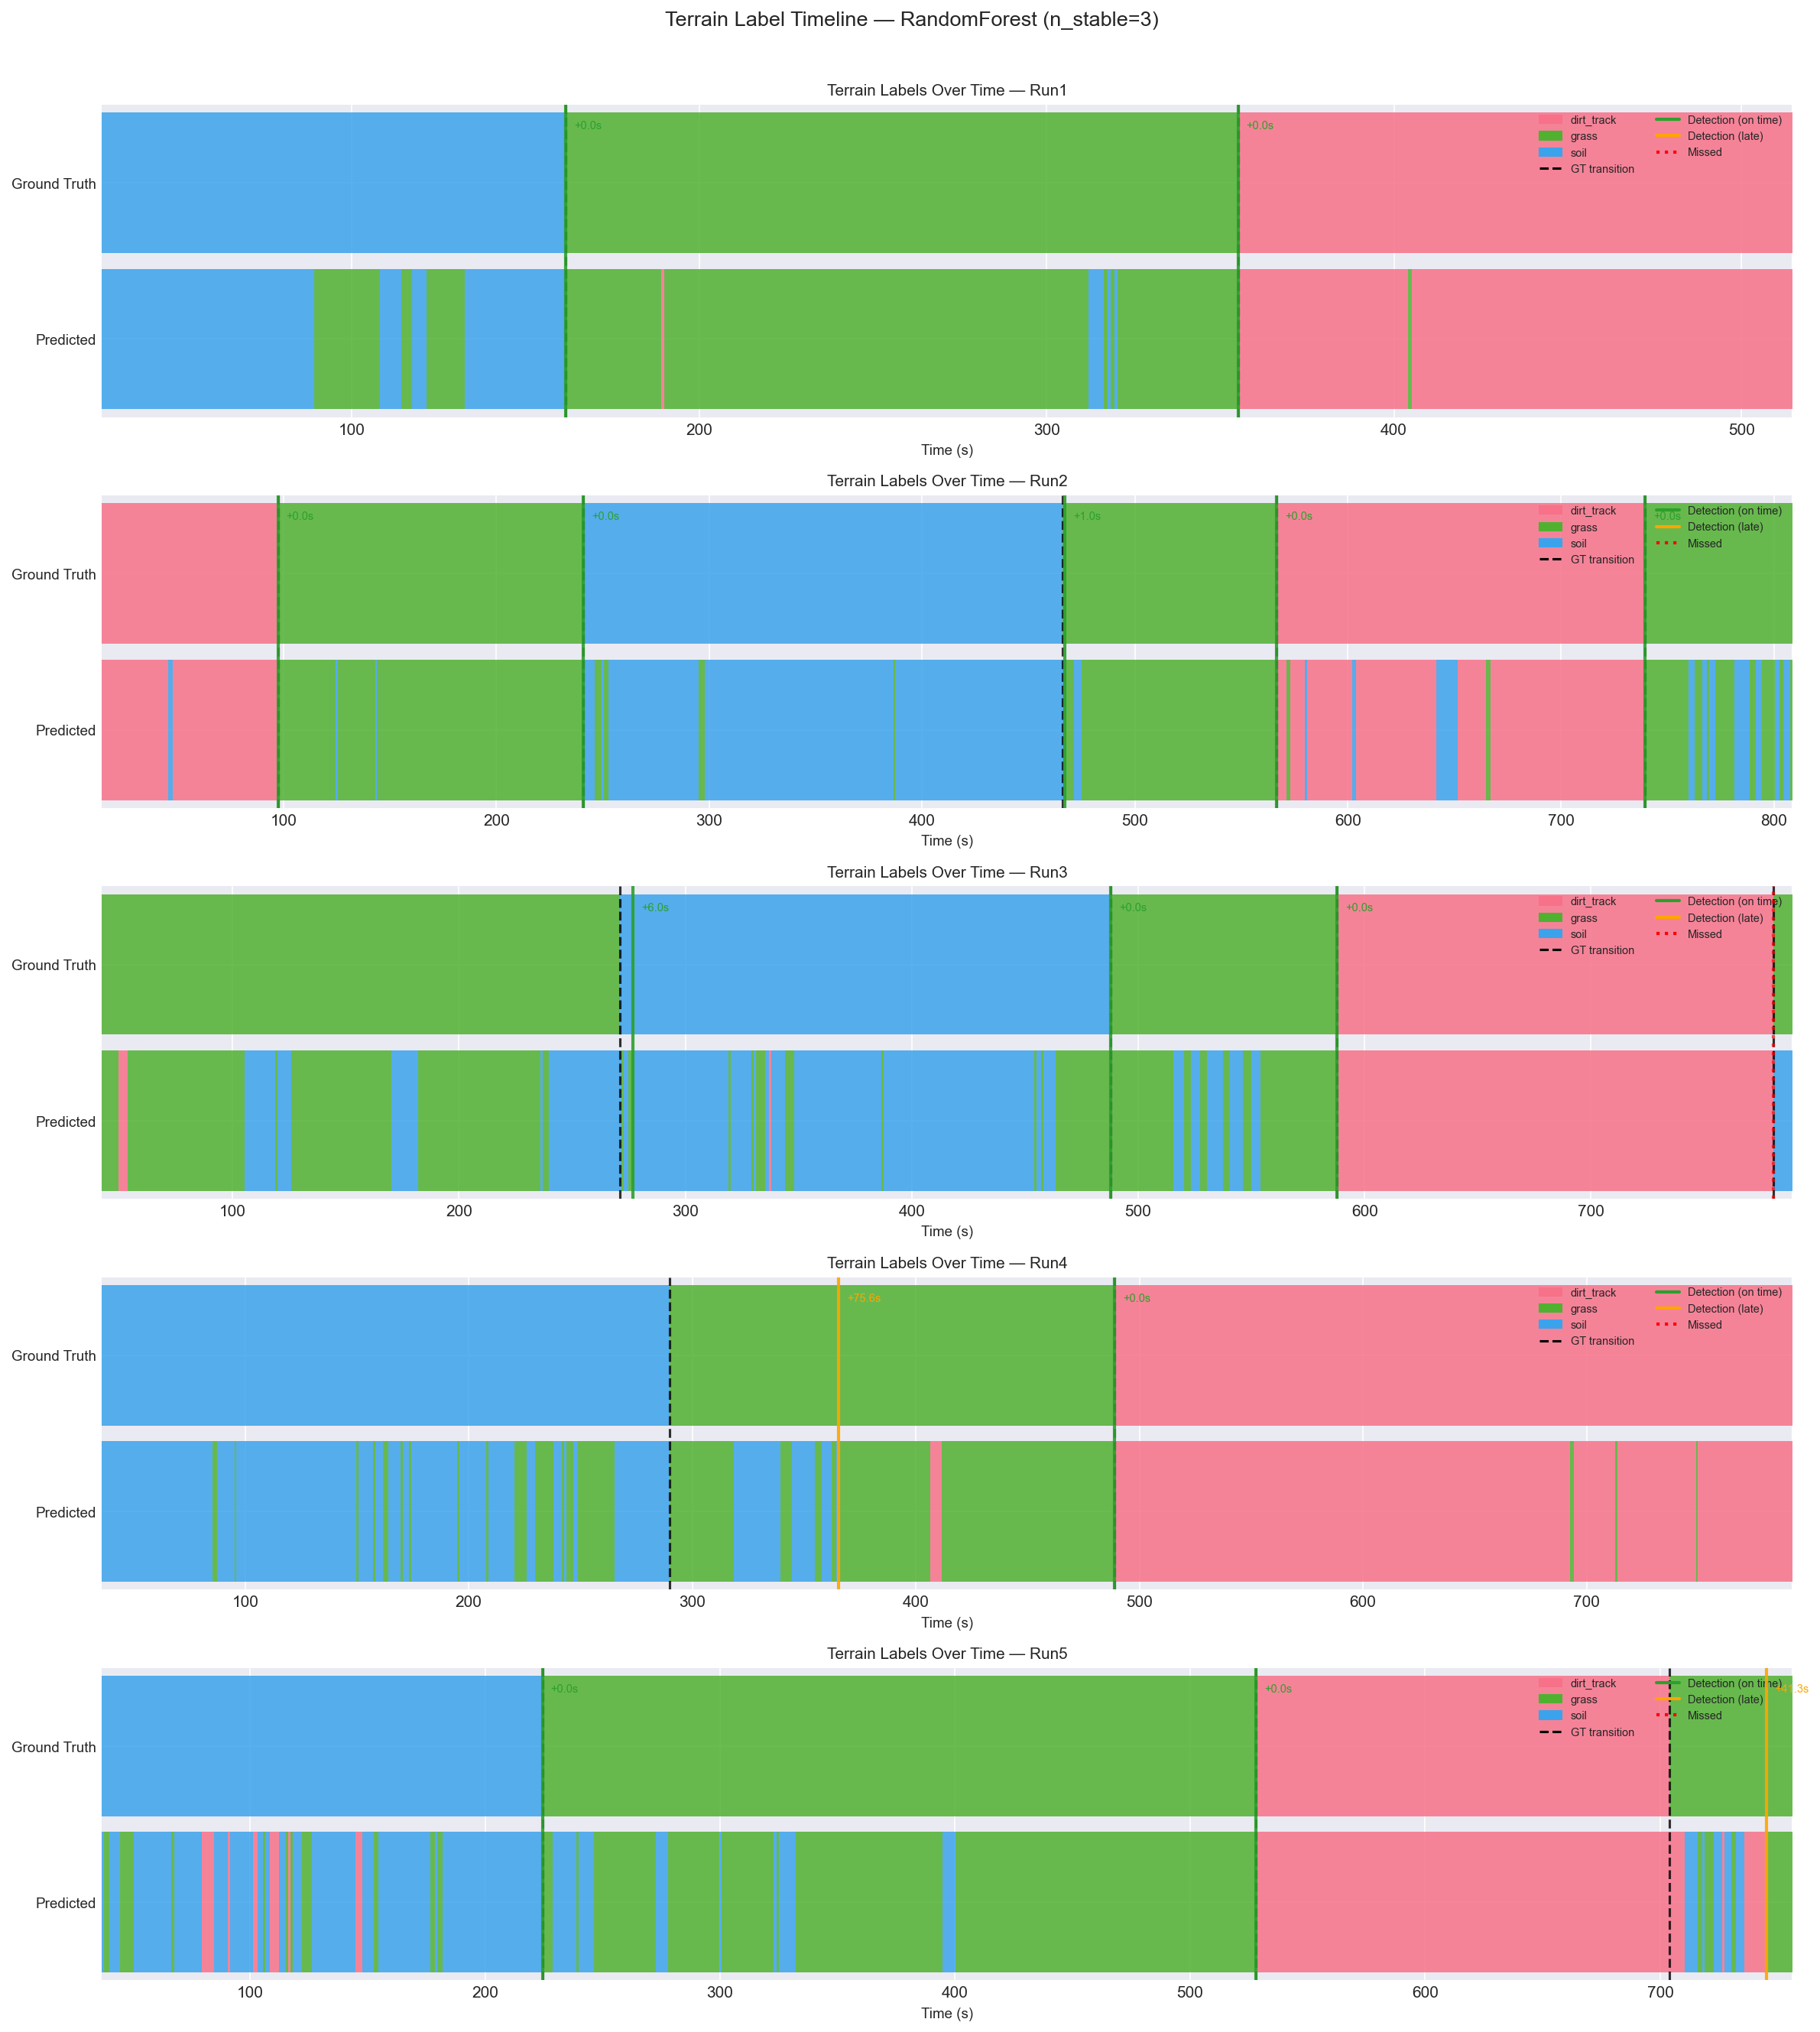

In [10]:
TIMELINE_MODEL = "RandomForest"  # change to any model in predictions

fig, axes = plt.subplots(
    len(run_ids), 1,
    figsize=(16, 3.5 * len(run_ids)),
    dpi=150,
)
if len(run_ids) == 1:
    axes = [axes]

for ax, run_id in zip(axes, run_ids):
    run_mask = df[RUN_COL] == run_id
    run_df = (
        df.loc[run_mask]
        .sort_values("t_start")
        .assign(
            time=lambda x: x["t_start"],
            true_label=lambda x: x[LABEL_COL],
            pred_label=predictions[TIMELINE_MODEL].loc[run_mask].values,
        )
        .reset_index(drop=True)
    )
    run_transitions = combined_transitions[
        (combined_transitions["run_id"] == run_id) &
        (combined_transitions["model"] == TIMELINE_MODEL)
    ]
    plot_transition_timeline(
        df=run_df,
        transitions_df=run_transitions,
        run_id=run_id,
        ax=ax,
        LABEL_ORDER=LABEL_ORDER,
    )

fig.suptitle(
    f"Terrain Label Timeline — {TIMELINE_MODEL} (n_stable={N_STABLE})",
    fontsize=13, y=1.01,
)
fig.tight_layout()
save_path = REPORTS_DIR / f"transition_timelines_{TIMELINE_MODEL.lower()}.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()

### 5.2 Detection Delay Distributions

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/Farm/transition_delay_histograms.png


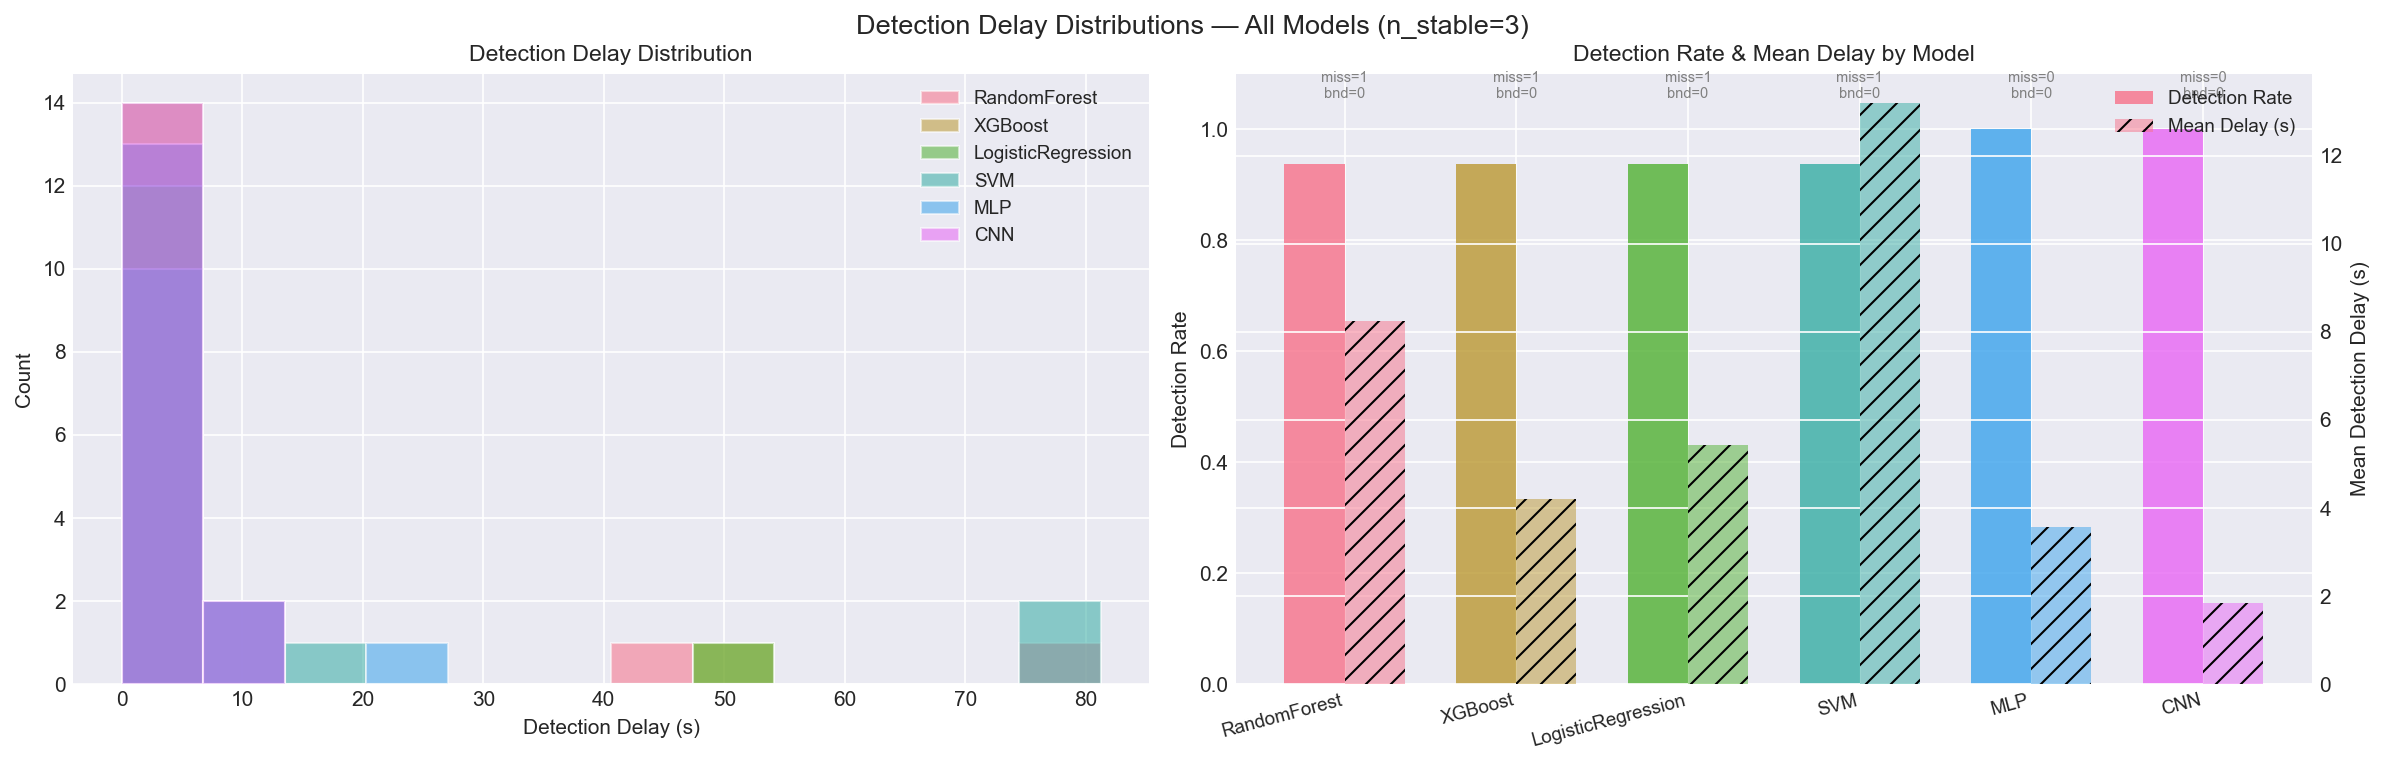

In [11]:
fig = plot_detection_delay_histogram(
    transitions_df=combined_transitions,
    bins=12,
    figsize=(16, 5),
)
fig.suptitle(
    f"Detection Delay Distributions — All Models (n_stable={N_STABLE})",
    fontsize=13, y=1.01,
)
save_path = REPORTS_DIR / "transition_delay_histograms.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()

## 6. Sensitivity Analysis — Effect of `n_stable`

Higher `n_stable` values require the model to commit to the new class for longer before we count a detection. This trades robustness against noisy single-window predictions for higher mean delay and possibly more missed transitions.

The two panels below show:
- **Left**: how detection rate changes as `n_stable` increases — models that oscillate between classes (e.g. SVM) degrade quickly.
- **Right**: how mean detection delay grows — models that commit stably early (e.g. MLP) stay near the minimum even at `n_stable=7`.

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/Farm/transition_sensitivity_n_stable.png


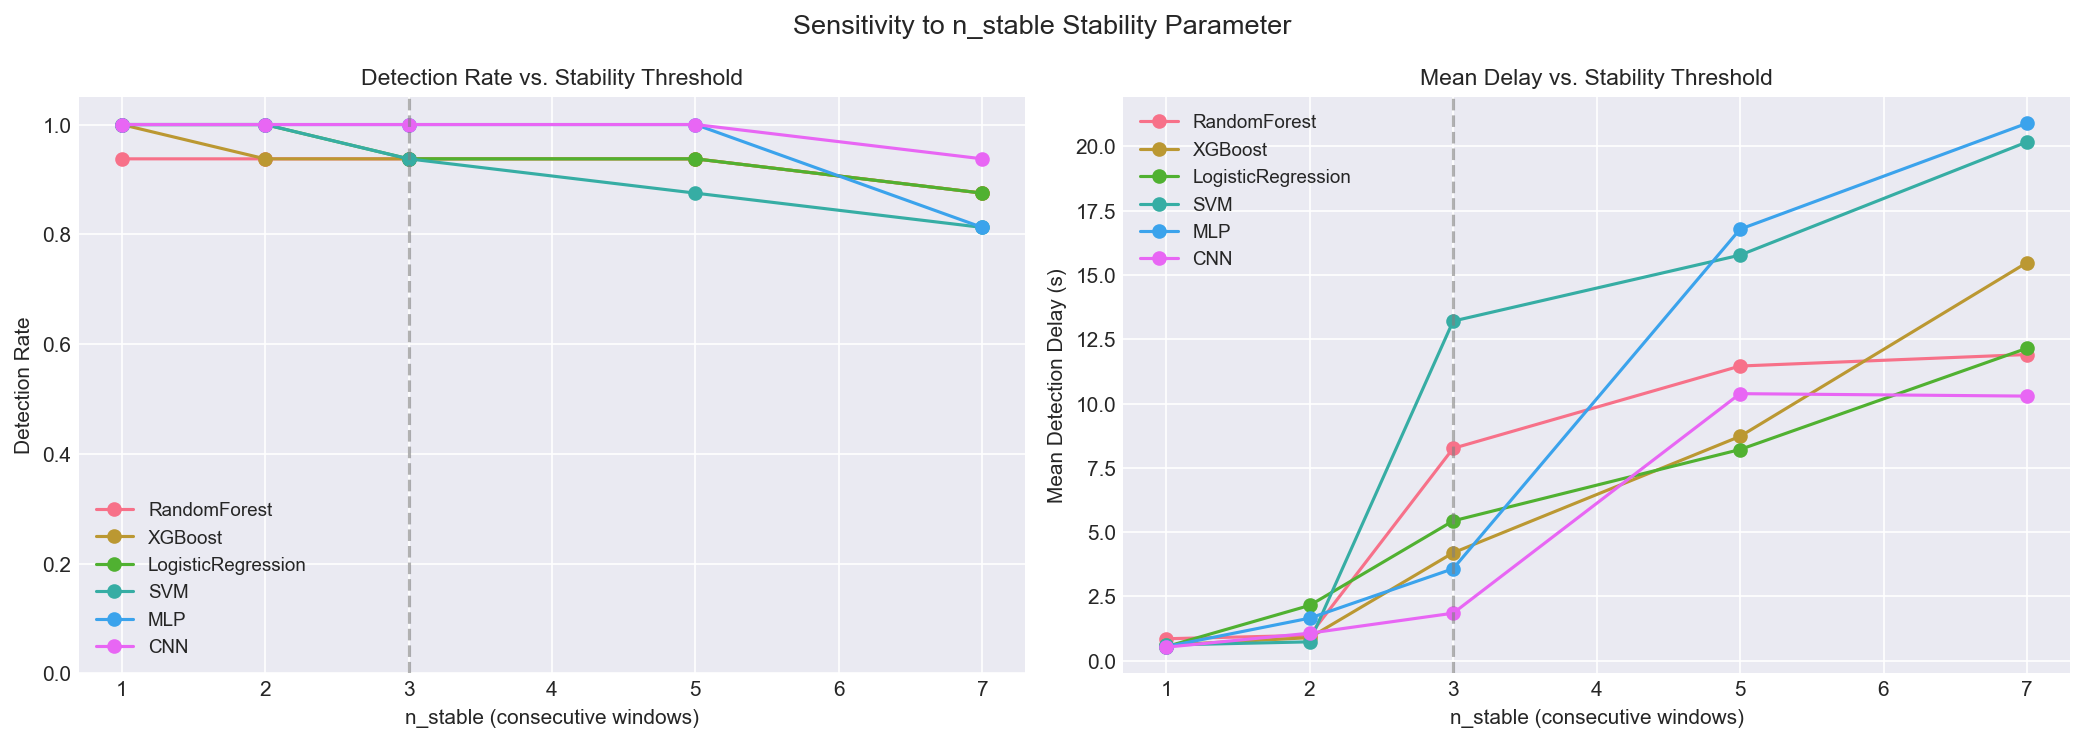

In [12]:
N_STABLE_VALUES = [1, 2, 3, 5, 7]
sensitivity_rows = []

for n_s in N_STABLE_VALUES:
    ct = compare_models(
        df=df,
        predictions_dict=predictions,
        time_col="t_start",
        true_col=LABEL_COL,
        run_col=RUN_COL,
        n_stable=n_s,
        threshold_sec=THRESHOLD_SEC,
    )
    for model_name in model_names:
        sub = ct[ct["model"] == model_name]
        det = sub[sub["outcome"] == "detected"]
        bnd = sub[sub["outcome"] == "boundary"]
        eff = len(sub) - len(bnd)
        sensitivity_rows.append({
            "n_stable": n_s,
            "model": model_name,
            "detection_rate": len(det) / eff if eff > 0 else float("nan"),
            "mean_delay_sec": det["detection_delay_sec"].mean(),
        })

sens_df = pd.DataFrame(sensitivity_rows)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)
palette = sns.color_palette("husl", len(model_names))

for i, model_name in enumerate(model_names):
    sub = sens_df[sens_df["model"] == model_name]
    axes[0].plot(sub["n_stable"], sub["detection_rate"],
                 marker="o", label=model_name, color=palette[i])
    axes[1].plot(sub["n_stable"], sub["mean_delay_sec"],
                 marker="o", label=model_name, color=palette[i])

axes[0].set_xlabel("n_stable (consecutive windows)", fontsize=10)
axes[0].set_ylabel("Detection Rate", fontsize=10)
axes[0].set_title("Detection Rate vs. Stability Threshold", fontsize=11)
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=9)
axes[0].axvline(N_STABLE, color="gray", linestyle="--", alpha=0.6, label=f"default={N_STABLE}")

axes[1].set_xlabel("n_stable (consecutive windows)", fontsize=10)
axes[1].set_ylabel("Mean Detection Delay (s)", fontsize=10)
axes[1].set_title("Mean Delay vs. Stability Threshold", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].axvline(N_STABLE, color="gray", linestyle="--", alpha=0.6, label=f"default={N_STABLE}")

fig.suptitle("Sensitivity to n_stable Stability Parameter", fontsize=13)
fig.tight_layout()
save_path = REPORTS_DIR / "transition_sensitivity_n_stable.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()

## 7. Summary Table

Aggregated transition outcomes across all 5 runs and 12 ground-truth transitions, using tuned hyperparameters for all models. The table is saved to `results/transition_analysis_summary.csv`.

In [13]:
summary_rows = []

for model_name in model_names:
    sub  = combined_transitions[combined_transitions["model"] == model_name]
    det  = sub[sub["outcome"] == "detected"]
    miss = sub[sub["outcome"] == "missed"]
    bnd  = sub[sub["outcome"] == "boundary"]
    eff  = len(sub) - len(bnd)
    delays = det["detection_delay_sec"].dropna()

    summary_rows.append({
        "Model": model_name,
        "GT Transitions": eff + len(bnd),
        "Detected": len(det),
        "Missed": len(miss),
        "Boundary": len(bnd),
        "Detection Rate": f"{len(det)/eff:.0%}" if eff > 0 else "N/A",
        "Mean Delay (s)": f"{delays.mean():.2f}" if len(delays) else "N/A",
        "Median Delay (s)": f"{delays.median():.2f}" if len(delays) else "N/A",
        "Max Delay (s)": f"{delays.max():.2f}" if len(delays) else "N/A",
        "Std Delay (s)": f"{delays.std():.2f}" if len(delays) else "N/A",
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model")

# Save
save_path = RESULTS_DIR / "transition_analysis_summary.csv"
summary_df.to_csv(save_path)
print(f"Saved summary to {save_path}")
print()

summary_df

Saved summary to /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/results/Farm/transition_analysis_summary.csv



,GT Transitions,Detected,Missed,Boundary,Detection Rate,Mean Delay (s),Median Delay (s),Max Delay (s),Std Delay (s)
Model,,,,,,,,,
RandomForest,16,15,1,0,94%,8.26,0.00,75.56,21.43
XGBoost,16,15,1,0,94%,4.20,0.00,49.49,12.72
LogisticRegression,16,15,1,0,94%,5.44,0.00,49.49,12.78
SVM,16,15,1,0,94%,13.21,0.00,77.35,26.28
MLP,16,16,0,0,100%,3.58,0.00,21.81,6.17
CNN,16,16,0,0,100%,1.85,0.00,11.71,3.58


## 8. Per-Transition-Type Breakdown

Terrain type pairs differ in their vibration signature similarity. Some transitions are structurally easier: `smooth_terrain → cobblestone` involves a large amplitude change and is expected to be detected rapidly. Others are harder: `grass → smooth_terrain` shows more gradual spectral differences, consistent with their lower per-class F1 scores in notebook 07.

The heatmap shows mean detection delay (seconds) per `(from → to)` pair and model. Grey/NaN = the model missed all instances of that transition type.

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/Farm/transition_delay_heatmap.png


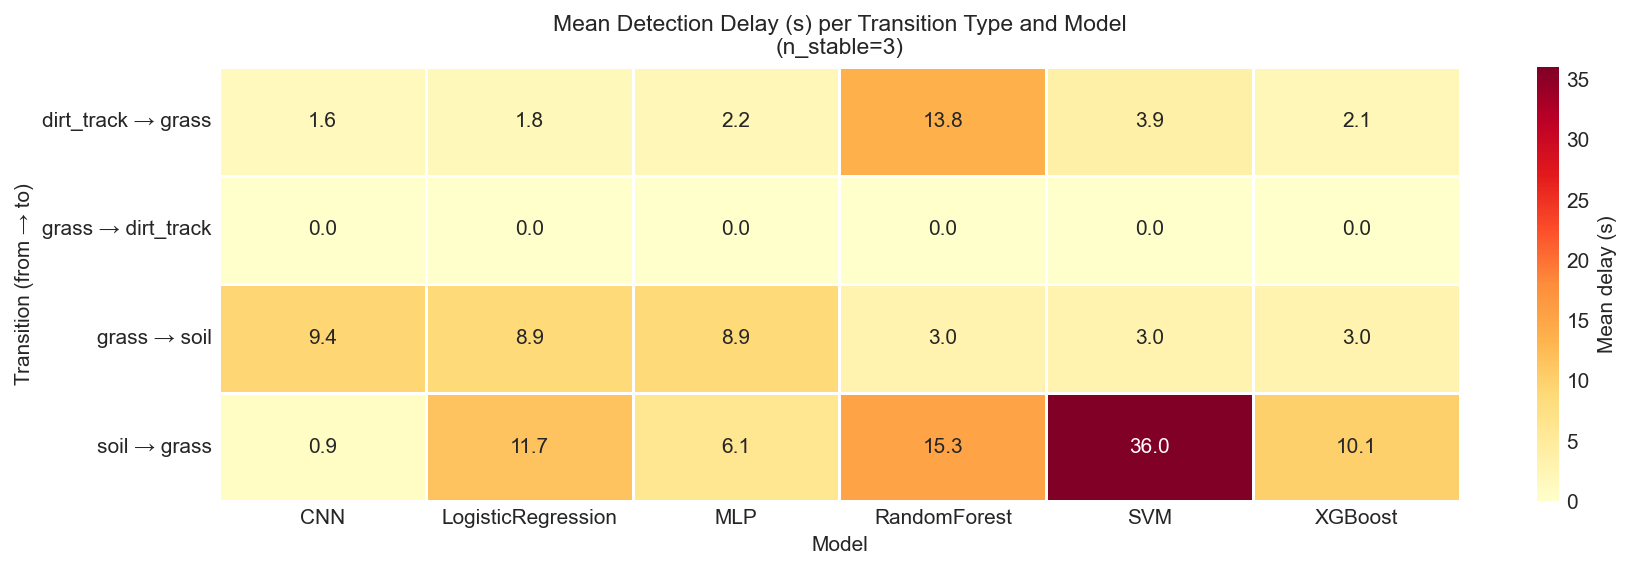

In [14]:
# Mean delay and detection rate per (from_label, to_label) pair, across all models
pair_df = (
    combined_transitions[combined_transitions["outcome"] == "detected"]
    .assign(transition_pair=lambda x: x["from_label"] + " → " + x["to_label"])
    .groupby(["transition_pair", "model"])["detection_delay_sec"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "mean_delay_s", "count": "n_detected"})
    .reset_index()
)

if not pair_df.empty:
    # Pivot for display
    pivot = pair_df.pivot(index="transition_pair", columns="model", values="mean_delay_s")
    fig, ax = plt.subplots(figsize=(12, max(3, len(pivot) * 0.6 + 1.5)), dpi=150)
    sns.heatmap(
        pivot,
        annot=True, fmt=".1f",
        cmap="YlOrRd",
        linewidths=0.5,
        ax=ax,
        cbar_kws={"label": "Mean delay (s)"},
    )
    ax.set_title(f"Mean Detection Delay (s) per Transition Type and Model\n(n_stable={N_STABLE})",
                 fontsize=11)
    ax.set_xlabel("Model", fontsize=10)
    ax.set_ylabel("Transition (from → to)", fontsize=10)
    fig.tight_layout()
    save_path = REPORTS_DIR / "transition_delay_heatmap.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {save_path}")
    plt.show()
else:
    print("No detected transitions to plot.")

## 9. CUSUM-based Change Detection (Blanke et al. §6.4)

The previous sections used a stable-run rule (`n_stable` consecutive windows of the new label) on hard predictions. That rule is oracle-driven (it needs to know which class to look for) and discards classifier confidence. Here is an online CUSUM detector that consumes the classifier's posterior probabilities, decides by itself whether a change happened and to which class, and reports a false-alarm rate alongside the detection rate.

Outputs use the same DataFrame schema as `compare_models()` so the existing timeline / histogram plots work without modification.


### 9.1 Generate posterior streams

Re-run LORO-CV with the `_proba` variants — same training loops as Section 3, but returning `(N_windows, C)` softmax/predict_proba matrices instead of hard labels. Cached to disk so the rest of the section is fast on re-runs.


In [15]:
# Cache directory for the posterior streams
PROBA_DIR = RESULTS_DIR / "probas"
PROBA_DIR.mkdir(parents=True, exist_ok=True)

# Each entry is (proba_matrix, classes_list).
# proba is row-aligned to df.index, so df + proba can be sliced together.
proba_dict: dict[str, tuple[np.ndarray, list[str]]] = {}

def _proba_path(name: str) -> Path:
    return PROBA_DIR / f"proba_{name}.npz"

def _load_or_compute(name: str, compute_fn):
    """Cache wrapper — load from disk if cached, else run compute_fn()."""
    p = _proba_path(name)
    if p.exists():
        z = np.load(p, allow_pickle=True)
        proba = z["proba"]
        classes = list(z["classes"])
        print(f"  loaded cached proba for {name}: shape={proba.shape}")
        return proba, classes
    print(f"  computing proba for {name}...")
    proba, classes, _ = compute_fn()
    np.savez(p, proba=proba, classes=np.array(classes, dtype=object))
    return proba, classes


In [16]:
# Classical models — predict_proba off the same fitted Pipeline.
# SVM is forced to probability=True inside the proba helper.
for model_name in CLASSICAL_MODELS:
    proba_dict[model_name] = _load_or_compute(
        model_name,
        lambda mn=model_name: run_classical_loro_cv_proba(
            df=df,
            feature_cols=feature_cols,
            label_col=LABEL_COL,
            run_col=RUN_COL,
            model_name=mn,
            imbalance="balanced",
            random_state=RANDOM_STATE,
            best_params=BEST_PARAMS,
        ),
    )


  computing proba for RandomForest...
  computing proba for XGBoost...
  computing proba for LogisticRegression...
  computing proba for SVM...


In [ ]:
# MLP — softmax pass over the same trained model
proba_dict["MLP"] = _load_or_compute(
    "MLP",
    lambda: run_mlp_loro_cv_proba(
        df=df,
        feature_cols=feature_cols,
        label_col=LABEL_COL,
        run_col=RUN_COL,
        hidden_dims=[256, 128, 64],
        dropout_rate=0.3,
        batch_size=32,
        max_epochs=200,
        patience=20,
        learning_rate=1e-3,
        weight_decay=1e-4,
        random_state=RANDOM_STATE,
    ),
)


  computing proba for MLP...
  MLP-proba fold Run1: acc=0.959
  MLP-proba fold Run2: acc=0.915
  MLP-proba fold Run3: acc=0.866
  MLP-proba fold Run4: acc=0.874
  MLP-proba fold Run5: acc=0.852


In [19]:
# CNN — softmax pass over raw windows
proba_dict["CNN"] = _load_or_compute(
    "CNN",
    lambda: run_cnn_loro_cv_proba(
        feature_df=df,
        cnn_df=cnn_df,
        label_col=LABEL_COL,
        run_col=RUN_COL,
        filters=CNN_FILTERS,
        kernels=CNN_KERNELS,
        dropout_rate=CNN_DROPOUT,
        batch_size=CNN_BATCH_SIZE,
        max_epochs=100,
        patience=15,
        learning_rate=CNN_LR,
        weight_decay=CNN_WEIGHT_DECAY,
        random_state=RANDOM_STATE,
    ),
)

print("\nProba streams ready:")
for name, (p, cls) in proba_dict.items():
    print(f"  {name:<22}  shape={p.shape}  classes={cls}")


  computing proba for CNN...
  CNN-proba fold Run1: acc=0.964
  CNN-proba fold Run2: acc=0.915
  CNN-proba fold Run3: acc=0.869
  CNN-proba fold Run4: acc=0.884
  CNN-proba fold Run5: acc=0.867

Proba streams ready:
  RandomForest            shape=(1583, 3)  classes=['dirt_track', 'grass', 'soil']
  XGBoost                 shape=(1583, 3)  classes=['dirt_track', 'grass', 'soil']
  LogisticRegression      shape=(1583, 3)  classes=['dirt_track', 'grass', 'soil']
  SVM                     shape=(1583, 3)  classes=['dirt_track', 'grass', 'soil']
  MLP                     shape=(1583, 3)  classes=['dirt_track', 'grass', 'soil']
  CNN                     shape=(1583, 3)  classes=['dirt_track', 'grass', 'soil']


### 9.2 Calibrate threshold *h* per model

Following Algorithm 6.6 of Blanke et al., Pick `h` per model so that on stationary segments of the LORO predictions, the empirical mean time between false alarms (MTBFA) ≈ a target value. Models with sharper posteriors will need a larger `h` for the same MTBFA, which is fine — what matters is comparing them at the same false-alarm budget.


In [20]:
# Target MTBFA: one false alarm every 60 s of stationary signal.
# Generous enough that the detector isn't paralysed; strict enough to
# hurt models that emit noisy posteriors.
TARGET_MTBFA_SEC = 60.0
WINDOW_STEP_SEC = 1.0
GRACE_WINDOWS = 1            # alarm in the window just before t_k still counts
WARMUP_WINDOWS = 0            # no warm-up by default; bump up if needed

h_dict: dict[str, float] = {}
h_grid_default = np.linspace(1.0, 80.0, 80)
true_labels_full = df[LABEL_COL].astype(str).to_numpy()

for model_name, (proba, classes) in proba_dict.items():
    cal = calibrate_threshold(
        proba_train=proba,
        labels_train=true_labels_full,
        classes=classes,
        target_mtbfa_sec=TARGET_MTBFA_SEC,
        step_sec=WINDOW_STEP_SEC,
        h_grid=h_grid_default,
    )
    h_dict[model_name] = cal["h"]
    print(f"  {model_name:<22}  h = {cal['h']:5.2f}   "
          f"(MTBFA on training segs ≈ {TARGET_MTBFA_SEC:.0f}s)")


  RandomForest            h =  3.00   (MTBFA on training segs ≈ 60s)
  XGBoost                 h =  7.00   (MTBFA on training segs ≈ 60s)
  LogisticRegression      h =  5.00   (MTBFA on training segs ≈ 60s)
  SVM                     h =  5.00   (MTBFA on training segs ≈ 60s)
  MLP                     h =  8.00   (MTBFA on training segs ≈ 60s)
  CNN                     h =  8.00   (MTBFA on training segs ≈ 60s)


### 9.3 Run CUSUM detector and match against ground truth

Same matching rule as Section 4: each GT transition is paired with the first alarm in `[t_k - grace, t_{k+1})`. New outcome `wrong_class` is produced when the detector fires in time but picks the wrong terrain. Alarms outside any GT window are accumulated as false alarms.


In [21]:
cusum_transitions, cusum_false_alarms = compare_models_cusum(
    df=df,
    proba_dict=proba_dict,
    h_dict=h_dict,
    time_col="t_start",
    true_col=LABEL_COL,
    run_col=RUN_COL,
    grace_windows=GRACE_WINDOWS,
    n_stable=N_STABLE,           # only used for the boundary rule, for parity
    threshold_sec=THRESHOLD_SEC,
    warmup=WARMUP_WINDOWS,
)

print(f"CUSUM transitions records: {len(cusum_transitions)}")
print(f"CUSUM false alarms       : {len(cusum_false_alarms)}")


CUSUM transitions records: 96
CUSUM false alarms       : 118


### 9.4 Comparison table

Detection rate, mean delay, wrong-class rate, and false-alarm rate per model. The first three are directly comparable to the Section 4 table; the last column (false alarms / minute) is new — the `n_stable` detector couldn't measure it.


In [22]:
# Total stationary time across all runs — used as 'exposure' for FA/min
_run_durations = []
for run_id in run_ids:
    t = df.loc[df[RUN_COL] == run_id, "t_start"].to_numpy()
    if len(t) > 1:
        _run_durations.append(t.max() - t.min())
TOTAL_RUN_SEC = float(np.sum(_run_durations))

model_names = list(proba_dict.keys())
print(f"{'Model':<22}  {'h':>6}  {'Detected':>8}  {'Wrong':>5}  {'Missed':>6}  "
      f"{'Bnd':>4}  {'Det.Rate':>8}  {'MeanDelay':>9}  {'FA/min':>7}")
print("-" * 95)
for m in model_names:
    sub = cusum_transitions[cusum_transitions["model"] == m]
    n_det = int((sub["outcome"] == "detected").sum())
    n_wrong = int((sub["outcome"] == "wrong_class").sum())
    n_miss = int((sub["outcome"] == "missed").sum())
    n_bnd = int((sub["outcome"] == "boundary").sum())
    eff = len(sub) - n_bnd
    rate = n_det / eff if eff > 0 else float("nan")
    mean_d = sub.loc[sub["outcome"] == "detected", "detection_delay_sec"].mean()
    n_fa = int((cusum_false_alarms["model"] == m).sum())
    fa_per_min = n_fa / (TOTAL_RUN_SEC / 60.0) if TOTAL_RUN_SEC > 0 else float("nan")
    print(f"{m:<22}  {h_dict[m]:>6.2f}  {n_det:>8}  {n_wrong:>5}  {n_miss:>6}  "
          f"{n_bnd:>4}  {rate:>8.1%}  {mean_d:>8.2f}s  {fa_per_min:>6.2f}")


Model                        h  Detected  Wrong  Missed   Bnd  Det.Rate  MeanDelay   FA/min
-----------------------------------------------------------------------------------------------
RandomForest              3.00        12      3       1     0     75.0%      4.08s    0.34
XGBoost                   7.00        14      2       0     0     87.5%      4.17s    0.33
LogisticRegression        5.00        13      2       1     0     81.2%      3.11s    0.33
SVM                       5.00        13      3       0     0     81.2%      3.74s    0.33
MLP                       8.00        15      1       0     0     93.8%      4.98s    0.31
CNN                       8.00        15      1       0     0     93.8%      5.84s    0.39


### 9.5 Timeline with CUSUM alarms overlaid

Same `plot_transition_timeline()` as Section 5.1 — feeding it the `cusum_transitions` DataFrame instead of `combined_transitions`. Detected (green) / wrong-class (orange) / missed (red) bars are placed at the alarm times rather than at first stable-run window.


Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/Farm/cusum_timeline_randomforest.png


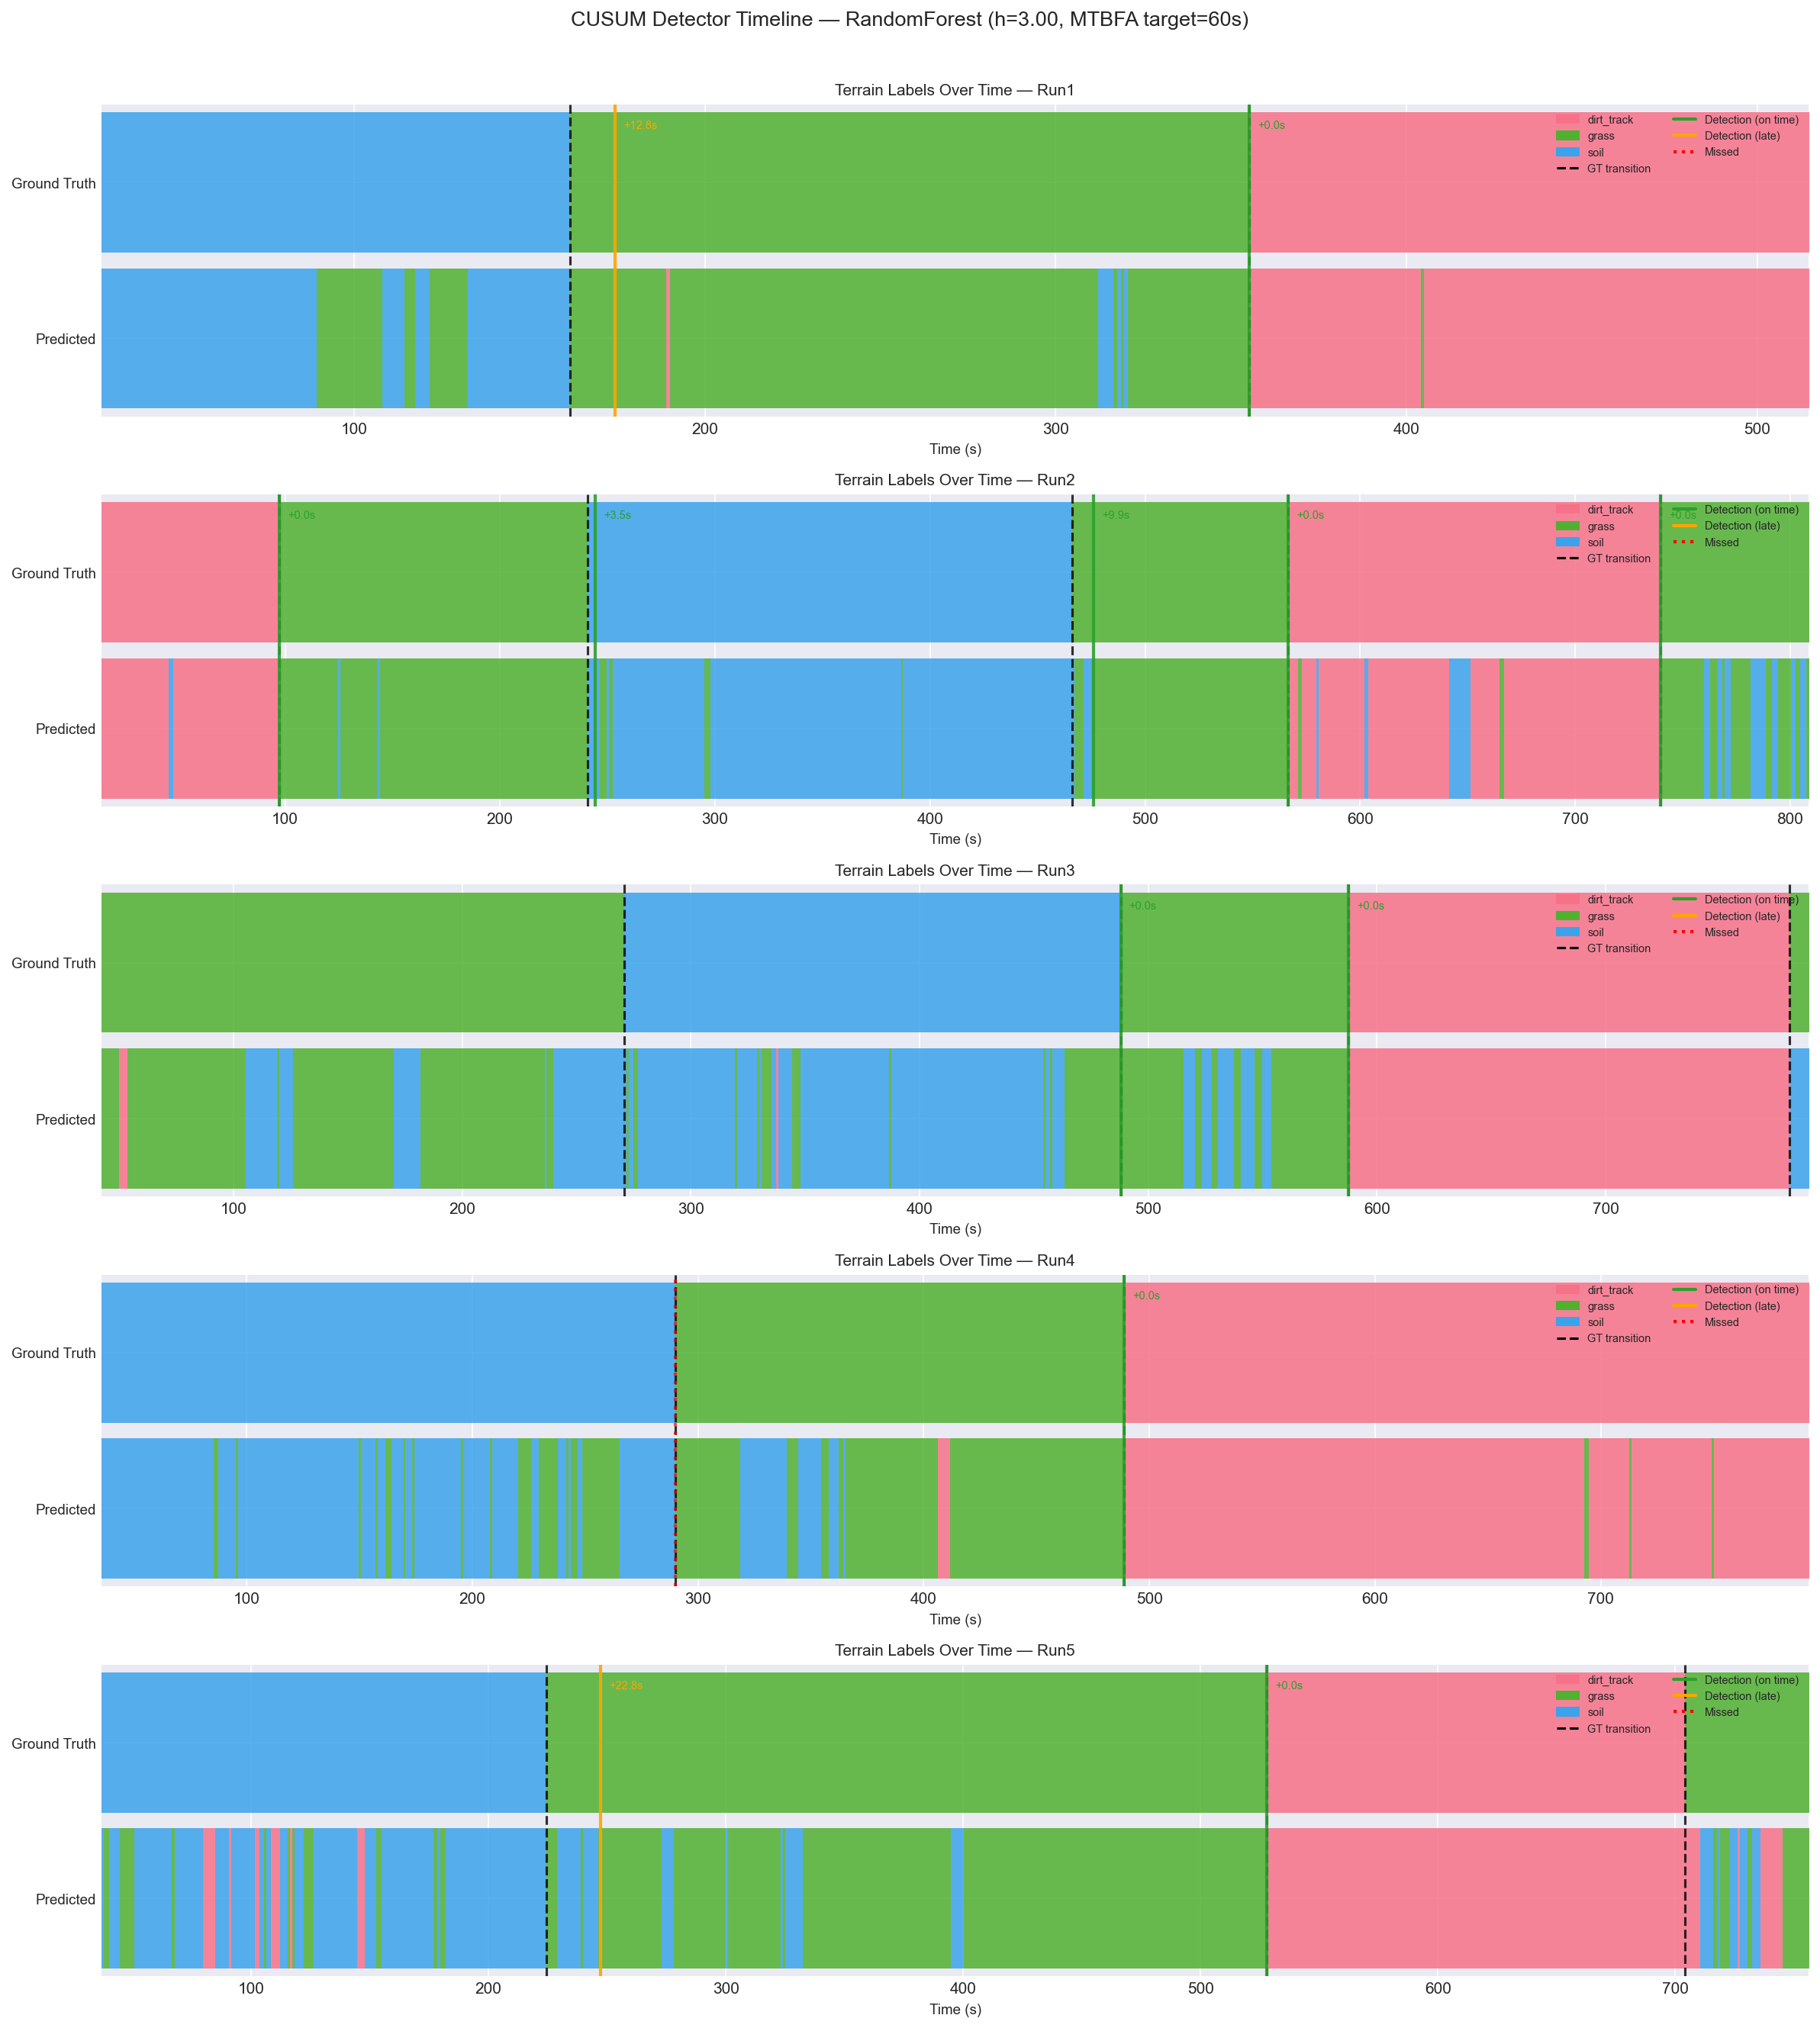

In [23]:
TIMELINE_MODEL_CUSUM = TIMELINE_MODEL  # reuse the same model selector
_proba_full, _classes = proba_dict[TIMELINE_MODEL_CUSUM]

# Hard prediction stream for the bottom band of the plot — argmax of proba
_argmax_pred = np.array(_classes)[np.argmax(_proba_full, axis=1)]
_pred_series = pd.Series(_argmax_pred, index=df.index)

fig, axes = plt.subplots(
    len(run_ids), 1,
    figsize=(16, 3.5 * len(run_ids)),
    dpi=150,
)
if len(run_ids) == 1:
    axes = [axes]

for ax, run_id in zip(axes, run_ids):
    run_mask = df[RUN_COL] == run_id
    run_df = (
        df.loc[run_mask]
        .sort_values("t_start")
        .assign(
            time=lambda x: x["t_start"],
            true_label=lambda x: x[LABEL_COL],
            pred_label=_pred_series.loc[run_mask].values,
        )
        .reset_index(drop=True)
    )
    run_trans = cusum_transitions[
        (cusum_transitions["run_id"] == str(run_id)) &
        (cusum_transitions["model"] == TIMELINE_MODEL_CUSUM)
    ]
    plot_transition_timeline(
        df=run_df,
        transitions_df=run_trans,
        run_id=run_id,
        ax=ax,
        LABEL_ORDER=LABEL_ORDER,
    )

fig.suptitle(
    f"CUSUM Detector Timeline — {TIMELINE_MODEL_CUSUM} "
    f"(h={h_dict[TIMELINE_MODEL_CUSUM]:.2f}, MTBFA target={TARGET_MTBFA_SEC:.0f}s)",
    fontsize=13, y=1.01,
)
fig.tight_layout()
save_path = REPORTS_DIR / f"cusum_timeline_{TIMELINE_MODEL_CUSUM.lower()}.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()


### 9.6 Operating curve (delay vs false-alarm rate)

Sweep `h` for each model and plot mean detection delay against false-alarm rate. This is the §6.4 analogue of the `n_stable` sensitivity sweep in Section 6 — the lower-left corner is the best operating point. Curves that crowd the bottom-left (low delay at low FA rate) are the stronger detectors.


  sweeping RandomForest...
  sweeping XGBoost...
  sweeping LogisticRegression...
  sweeping SVM...
  sweeping MLP...
  sweeping CNN...
Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/Farm/cusum_operating_curves.png


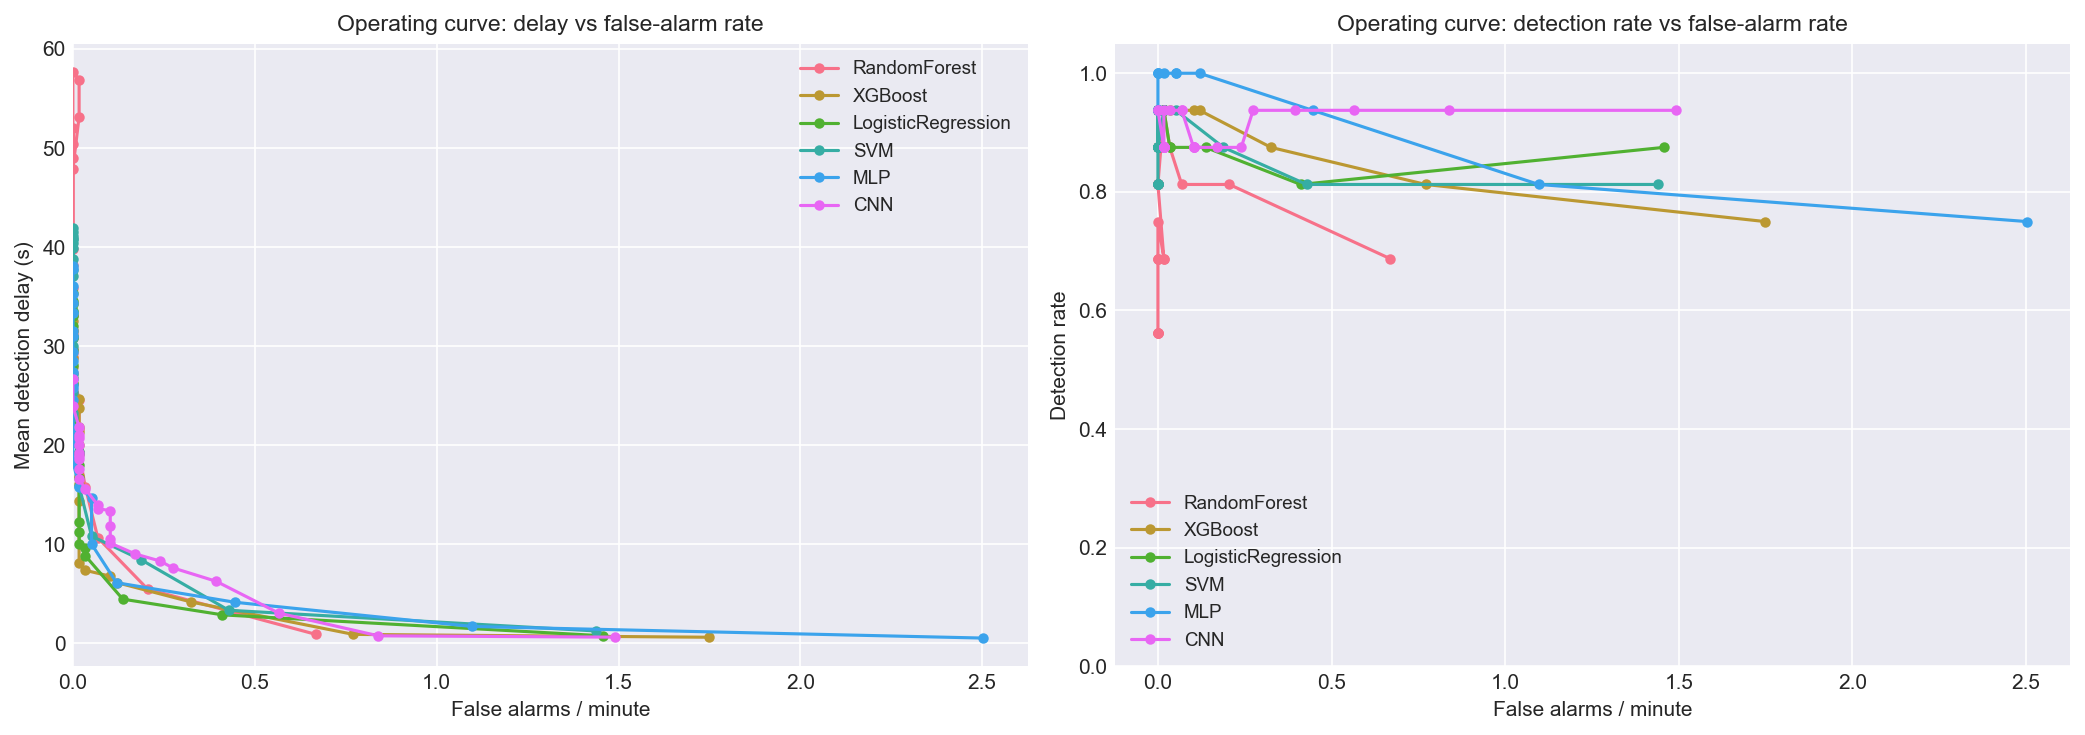

In [24]:
OP_CURVE_H_GRID = np.linspace(2.0, 60.0, 25)

op_curves: dict[str, pd.DataFrame] = {}
for model_name, (proba, classes) in proba_dict.items():
    print(f"  sweeping {model_name}...")
    op_curves[model_name] = operating_curve(
        df=df,
        proba_full=proba,
        classes=classes,
        h_grid=OP_CURVE_H_GRID,
        time_col="t_start",
        true_col=LABEL_COL,
        run_col=RUN_COL,
        grace_windows=GRACE_WINDOWS,
        n_stable=N_STABLE,
        threshold_sec=THRESHOLD_SEC,
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)
palette = sns.color_palette("husl", len(op_curves))

ax = axes[0]
for c, (name, curve) in zip(palette, op_curves.items()):
    ax.plot(curve["false_alarm_rate_per_min"], curve["mean_delay_sec"],
            "-o", color=c, label=name, markersize=4, linewidth=1.5)
ax.set_xlabel("False alarms / minute", fontsize=10)
ax.set_ylabel("Mean detection delay (s)", fontsize=10)
ax.set_title("Operating curve: delay vs false-alarm rate", fontsize=11)
ax.legend(fontsize=9, loc="best")
ax.set_xlim(left=0)

ax = axes[1]
for c, (name, curve) in zip(palette, op_curves.items()):
    ax.plot(curve["false_alarm_rate_per_min"], curve["detection_rate"],
            "-o", color=c, label=name, markersize=4, linewidth=1.5)
ax.set_xlabel("False alarms / minute", fontsize=10)
ax.set_ylabel("Detection rate", fontsize=10)
ax.set_title("Operating curve: detection rate vs false-alarm rate", fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9, loc="best")

fig.tight_layout()
save_path = REPORTS_DIR / "cusum_operating_curves.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()


### 9.7 Notes on the comparison

The CUSUM detector and the `n_stable` rule answer slightly different questions:
- `n_stable` measures how long after a known transition the classifier   commits to the new (known) label. It cannot be wrong about the class,   because the class to look for is fed in.
- CUSUM measures how long after a transition the classifier accumulates   enough evidence to flip — without being told what to flip to. It can   be wrong (`wrong_class`), and it can fire when nothing happened   (false alarm).

When the detection rate of a model is similar under both, the model is not just classifying well per-window — it is also producing posteriors whose log-odds carry the change information cleanly.
